In [2]:
import pandas as pd
import numpy as np

In [3]:


# path to your exported file
file = "dispersion_curve_test_A_Lamb.txt"

# read file (it is comma-separated)
df = pd.read_csv(file)

print(df.head())
print(df.columns)

   A0 f (kHz)  A0 Phase velocity (m/ms)  A0 Energy velocity (m/ms)  \
0       0.001                  0.005380                   0.010760   
1       0.300                  0.092852                   0.184360   
2       0.600                  0.130836                   0.257932   
3       0.900                  0.159662                   0.312564   
4       1.200                  0.183700                   0.357156   

   A0 Propagation time (micsec)  A0 Coincidence angle (deg)  \
0                   9293.303181                        90.0   
1                    542.418299                        90.0   
2                    387.698992                        90.0   
3                    319.934532                        90.0   
4                    279.989807                        90.0   

   A0 Wavelength (mm)  A0 Wavenumber (rad/mm)  A0 Attenuation (Np/m)  \
0         5380.343685                0.001168                      0   
1          309.505214                0.020301           

In [4]:

f_A0 = df["A0 f (kHz)"].values
c_A0 = df["A0 Phase velocity (m/ms)"].values

# Remove NaNs (important: higher modes end earlier)
mask = ~np.isnan(f_A0) & ~np.isnan(c_A0)

f_A0 = f_A0[mask]
c_A0 = c_A0[mask]

In [6]:
# f_A0 = f_A0 * 1e3        # kHz → Hz
c_A0 = c_A0 * 1e3        # m/ms → m/s

In [10]:
# k_A0 = df["A0 Wavenumber (rad/mm)"].values
# k_A0 = k_A0 * 1e3        # rad/mm → rad/m

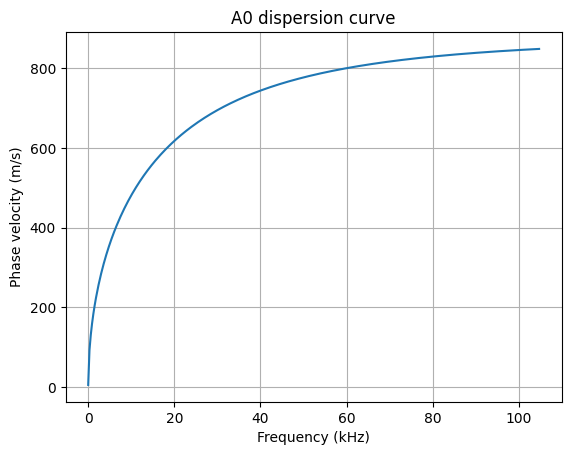

In [12]:
import matplotlib.pyplot as plt

plt.plot(f_A0[:350], c_A0[:350])
plt.xlabel("Frequency (kHz)")
plt.ylabel("Phase velocity (m/s)")
plt.title("A0 dispersion curve")
plt.grid()
plt.show()

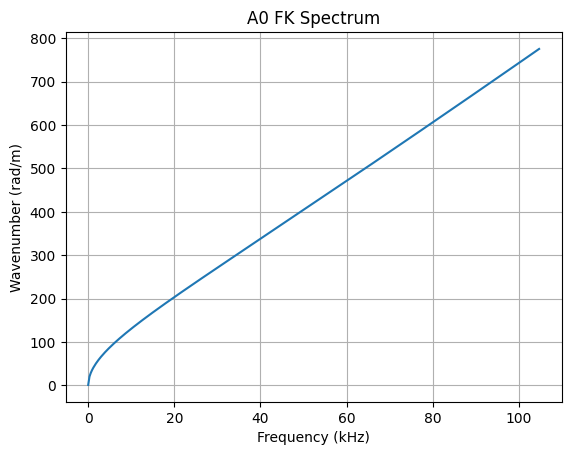

In [14]:
# plot the fk spectrum
k_A0 = df["A0 Wavenumber (rad/mm)"].values
k_A0 = k_A0 * 1e3        # rad/mm → rad/m
plt.plot(f_A0[:350], k_A0[:350] )
plt.xlabel("Frequency (kHz)")
plt.ylabel("Wavenumber (rad/m)")
plt.title("A0 FK Spectrum")
plt.grid()
plt.show()